Environment Setup and Validation Primitives

In [1]:
import sys
from pathlib import Path
from typing import Callable, Any, Optional
from rich import print

sys.path.append(str(Path.cwd().parent))

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

CACHE_DIR = Path("utils/.cache/optimization_diagnostics")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

#### Core Infrastructure Initialization

In [2]:
from utils.toy_city import toy_setup_from_yaml
from utils.route import RouteGenerator, RouteSystem
from utils.pheromone import PheromoneMatrix
from utils.local_search import ACOLocalSearch
from utils.genetic import Chromosome, MemeticAlgorithm

print("[OPTIMIZATION SETUP] Instantiating physical topology...")
city, sampler, cfg = toy_setup_from_yaml('configs/toy_city_configs.yaml')

TARGET_ROUTE_COUNT = 16

print("[OPTIMIZATION SETUP] Generating natural route clusters via demand sampling...")
rg = RouteGenerator(city_graph=city, sampler=sampler, verbose=False)
parent_a_routes = [rg.generate(n_points=4) for _ in range(TARGET_ROUTE_COUNT)]
parent_b_routes = [rg.generate(n_points=4) for _ in range(TARGET_ROUTE_COUNT)]

print("[OPTIMIZATION SETUP] Constructing and diverging demand matrices...")
phero_a = PheromoneMatrix(city.graph, cfg)
phero_b = PheromoneMatrix(city.graph, cfg)

# Simulate natural generational divergence by depositing pheromones along respective routes
for route in parent_a_routes:
    for edge in route.path:
        phero_a.tau[edge] = phero_a.tau.get(edge, 0.0) + 10.0

for route in parent_b_routes:
    for edge in route.path:
        phero_b.tau[edge] = phero_b.tau.get(edge, 0.0) + 10.0

print("[OPTIMIZATION SETUP] Assembling Chromosomes...")
chrom_a = Chromosome(routes=parent_a_routes, allocation={}, pheromones=phero_a, generation=0)
chrom_b = Chromosome(routes=parent_b_routes, allocation={}, pheromones=phero_b, generation=0)

chrom_a.cost = 1500.0
chrom_b.cost = 800.0

engine = ACOLocalSearch(cg=city, base_window_size=10)
algo = MemeticAlgorithm(cg=city, local_search=engine, target_route_count=TARGET_ROUTE_COUNT)

[OPTIMIZATION SETUP] Instantiating physical topology...

[TOY CITY] Building 50×50 grid…
CityGraph(ToyCity(50×50)) | Nodes: 2500 | Edges: 9800 (Drivable: 9800) | Landmarks: []
[TOY DDM] Built demand surface over 2500 nodes (2500 drivable) using 11 hotspots.
  · [Downtown Public Market]  weight=15.0  nearest_node_prob=0.00076
  · [University Belt]  weight=12.0  nearest_node_prob=0.00061
  · [North Regional Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [South City Terminal]  weight=10.0  nearest_node_prob=0.00050
  · [Mega Mall Complex]  weight=9.0  nearest_node_prob=0.00045
  · [BPO / Tech Park]  weight=8.0  nearest_node_prob=0.00040
  · [City General Hospital]  weight=7.0  nearest_node_prob=0.00035
  · [Heavy Industrial Zone]  weight=6.0  nearest_node_prob=0.00030
  · [Suburban Residential (East)]  weight=3.0  nearest_node_prob=0.00015
  · [Suburban Residential (Northeast)]  weight=2.0  nearest_node_prob=0.00010
  · [Suburban Residential (Southwest)]  weight=2.5  nearest_node_prob=0.00013
  Demand contrast (max/min prob): 7.5×


[OPTIMIZATION SETUP] Generating natural route clusters via demand sampling...

[OPTIMIZATION SETUP] Constructing and diverging demand matrices...

[OPTIMIZATION SETUP] Assembling Chromosomes...

#### Genetic Operation Logic Verification

In [3]:
def verify_crossover_topological_hub():
    children = algo.crossover_topological_hub(chrom_a, chrom_b)
    if len(children) != TARGET_ROUTE_COUNT:
        raise ValueError(f"Target count constraint failed: {len(children)} routes returned.")
    return children

def verify_inherit_pheromones():
    child_phero = algo.inherit_pheromones(chrom_a, chrom_b)
    if not child_phero.tau:
        raise ValueError("Pheromone synthesis failed. Matrix is empty.")
    return child_phero

def verify_evaluate_chromosome_api_mismatch():
    algo.evaluate_chromosome(chrom_a, total_fleet=10)

print("Executing purely logical verification...")
validate_call("Logic: Crossover Topological Hub", True, verify_crossover_topological_hub)
validate_call("Logic: Inherit Pheromones", True, verify_inherit_pheromones)
validate_call("Logic: Evaluate Chromosome (API Mismatch Catch)", False, verify_evaluate_chromosome_api_mismatch)

Executing purely logical verification...

[VALIDATED] Logic: Crossover Topological Hub: Executed successfully.

[VALIDATED] Logic: Inherit Pheromones: Executed successfully.

[REJECTED] Logic: Evaluate Chromosome (API Mismatch Catch): Safely blocked with AttributeError('PheromoneMatrix' 
object has no attribute 'get_point')

#### Demand Density Visualization

DIRECT DEMAND MODEL SPATIAL DENSITY MAP

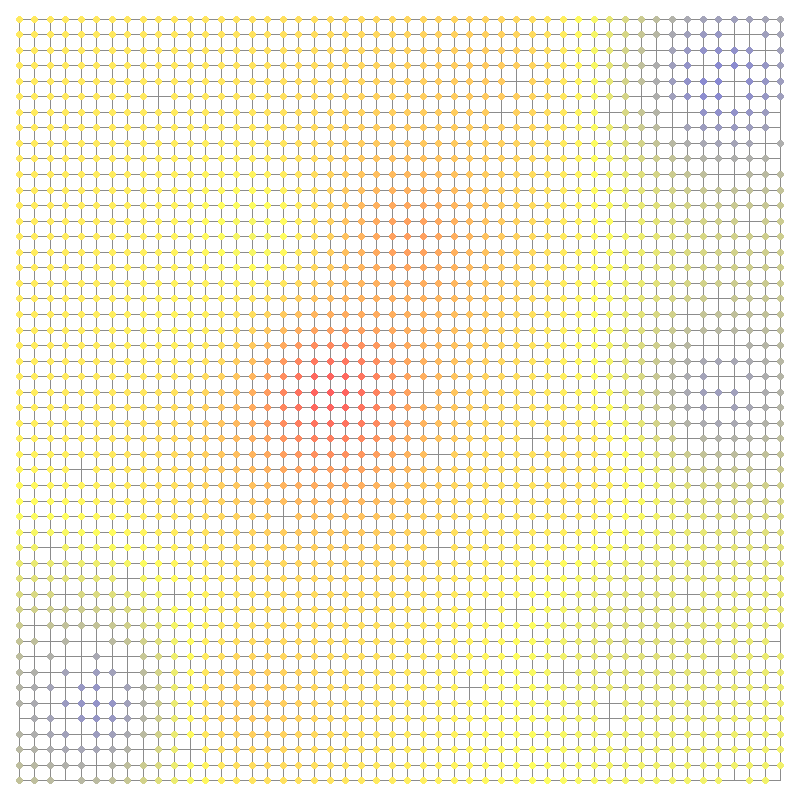

[VALIDATED] Visual: Demand Density Map: Executed successfully.

True

In [4]:
def visualize_demand_density():
    context = city.get_bounds()
    # Convert base image to RGBA to support alpha transparency for the density points
    base_img = city.draw(size=800, only_drivable=True).convert("RGBA")
    
    # Render 10,000 sample points to generate a smooth heatmap gradient
    sampler.draw_density(base_img, context, num_points=10000, only_drivable=True)
    
    print("DIRECT DEMAND MODEL SPATIAL DENSITY MAP")
    display(base_img)
    return True

validate_call("Visual: Demand Density Map", True, visualize_demand_density)

#### Visual Area-Based Crossover Diagnostic

Parent A: Visualizes the origin and shape of the extracted sub-graph.

Parent B: Illustrates how the secondary parent's routes geometrically intersect with the target anchor prior to 
splicing.

Child: Confirms the resulting system successfully integrated the foundation alongside the complementary routes.

TELEMETRY | Parent A Cost: 1500.00 | Parent B Cost: 800.00 | Child System Cost: N/A (API Mismatch)

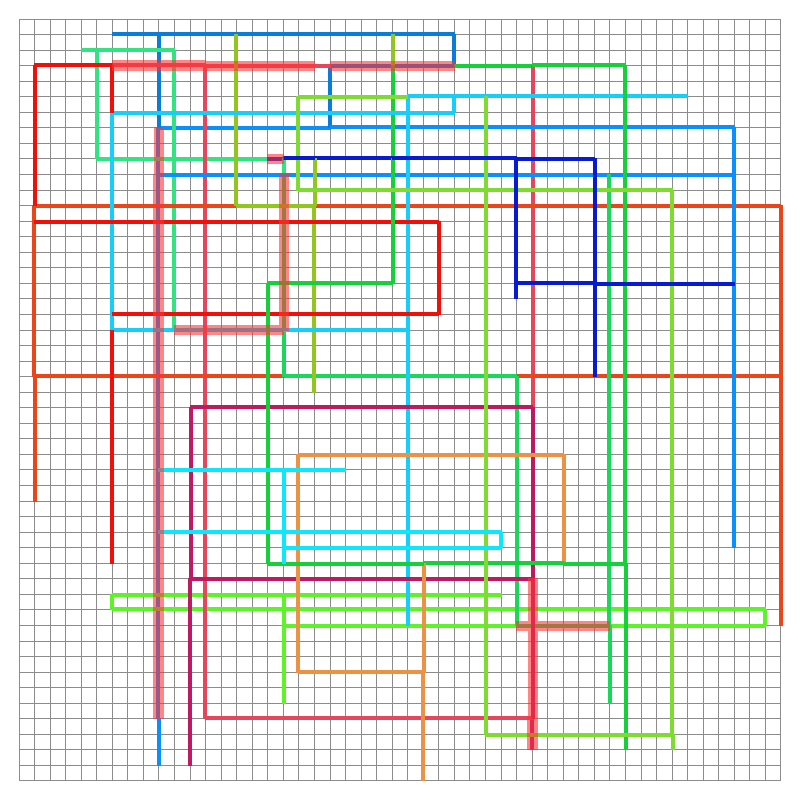

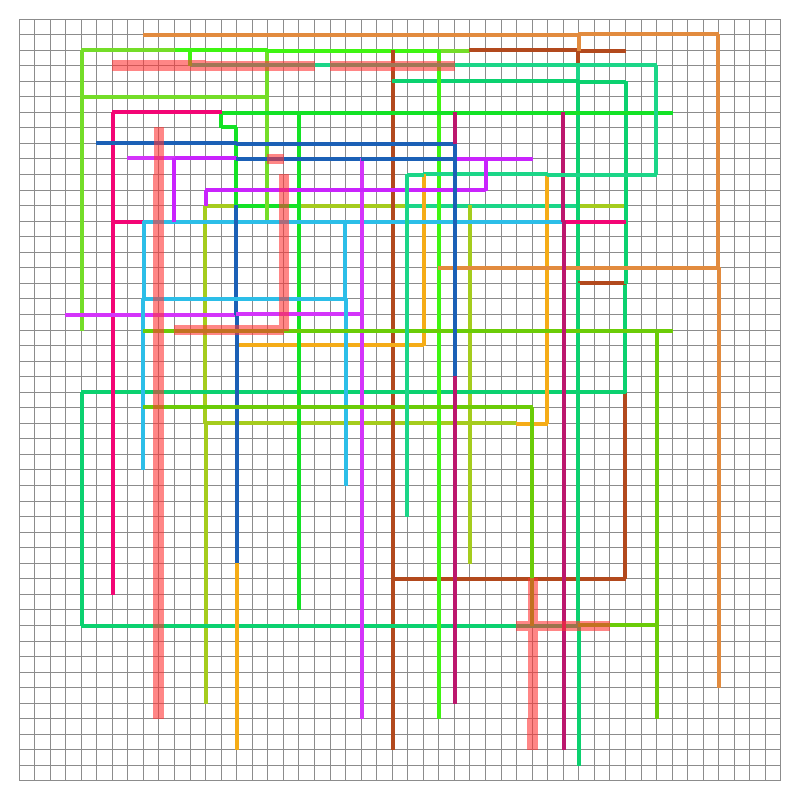

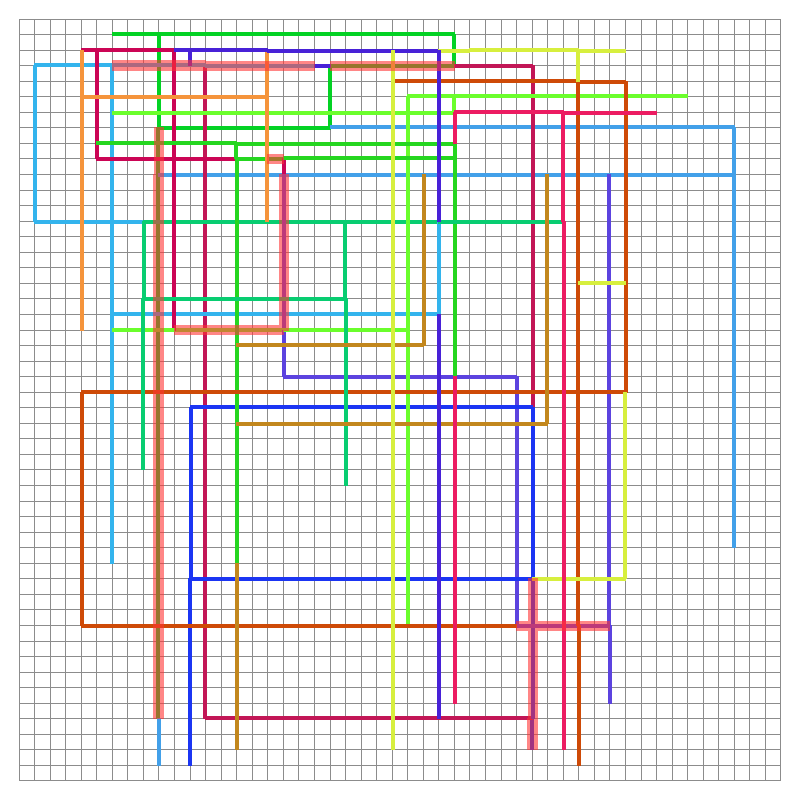

[VALIDATED] Visual: Topological Edge-Cluster Crossover: Executed successfully.

In [5]:
from PIL import Image, ImageDraw

def draw_topological_cluster(img: Image.Image, context: tuple, cg: Any, hub_edge_ids: set) -> Image.Image:
    """Highlights the specific structural edges forming the non-rectangular topological hub."""
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    (c_min_lon, c_max_lat), (c_max_lon, c_min_lat) = context
    img_w, img_h = img.size
    
    def to_px(lon, lat):
        x = (lon - c_min_lon) / (c_max_lon - c_min_lon) * img_w
        y = (c_max_lat - lat) / (c_max_lat - c_min_lat) * img_h
        return x, y
        
    for e in cg.graph:
        if getattr(e, 'id', id(e)) in hub_edge_ids:
            x0, y0 = to_px(e.start.lon, e.start.lat)
            x1, y1 = to_px(e.end.lon, e.end.lat)
            draw.line([(x0, y0), (x1, y1)], fill=(255, 50, 50, 150), width=10)
            
    return Image.alpha_composite(img.convert("RGBA"), overlay)

def visualize_crossover():
    context = city.get_bounds()
    base_img = city.draw(size=800, only_drivable=True).convert("RGBA")
    
    hub_edge_ids = algo._get_hub_edges(chrom_a.routes, chrom_a.pheromones)
    child_routes = algo.crossover_topological_hub(chrom_a, chrom_b)
    
    temp_child = Chromosome(routes=child_routes, allocation={}, pheromones=chrom_a.pheromones)
    try:
        algo.evaluate_chromosome(temp_child, total_fleet=15)
        child_cost_str = f"{temp_child.cost:.2f}"
    except AttributeError:
        child_cost_str = "N/A (API Mismatch)"
    
    rs_a = RouteSystem()
    for r in chrom_a.routes: rs_a.add_route(r)

    print("Parent A: Visualizes the origin and shape of the extracted sub-graph.")
    img_a = draw_topological_cluster(rs_a.draw(context, base_img.copy(), line_width=4, dash_length=0), context, city, hub_edge_ids)
    
    rs_b = RouteSystem()
    for r in chrom_b.routes: rs_b.add_route(r)
    print("Parent B: Illustrates how the secondary parent's routes geometrically intersect with the target anchor prior to splicing.")
    img_b = draw_topological_cluster(rs_b.draw(context, base_img.copy(), line_width=4, dash_length=0), context, city, hub_edge_ids)
    
    rs_child = RouteSystem()
    for r in child_routes: rs_child.add_route(r)
    print("Child: Confirms the resulting system successfully integrated the foundation alongside the complementary routes.")
    img_child = draw_topological_cluster(rs_child.draw(context, base_img.copy(), line_width=4, dash_length=0), context, city, hub_edge_ids)
    
    print(f"TELEMETRY | Parent A Cost: {chrom_a.cost:.2f} | Parent B Cost: {chrom_b.cost:.2f} | Child System Cost: {child_cost_str}")
    display(img_a, img_b, img_child)
    return child_routes

validate_call("Visual: Topological Edge-Cluster Crossover", True, visualize_crossover)

# TODO: CHECK % PARENT A ROUTES VS % PARENT B ROUTES TYPICAL RATIO

#### Visual Pheromone Inheritance Diagnostic

TELEMETRY | Parent A Cost: 1500.00 | Parent B Cost: 800.00 | Evaluated Child System Cost: N/A (API Mismatch)

--- ABSOLUTE DEMAND MATRICES ---

PARENT A (Top) | PARENT B (Middle) | CHILD (Bottom)

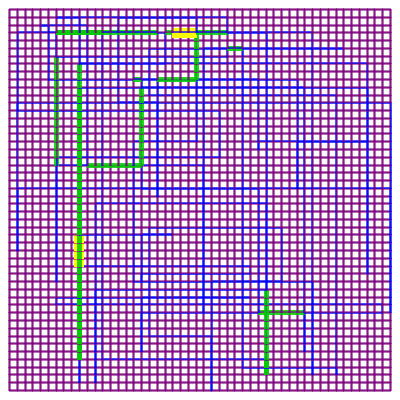

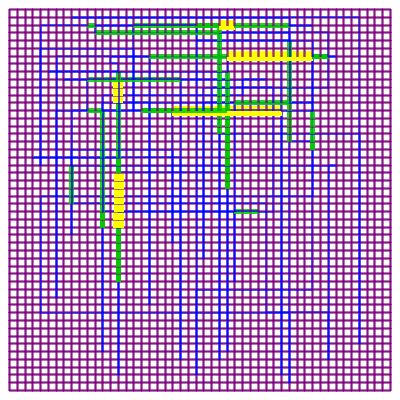

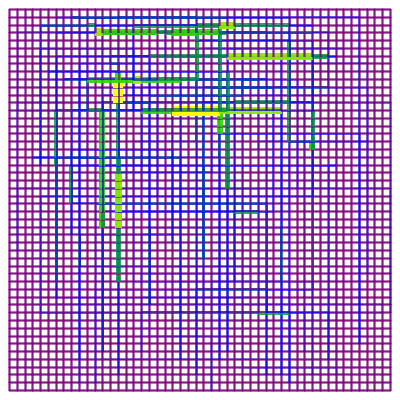

--- DIFFERENCE MAPS (Locked Scale) ---

PARENT A vs B (Top) | CHILD vs PARENT A (Middle) | CHILD vs PARENT B (Bottom)

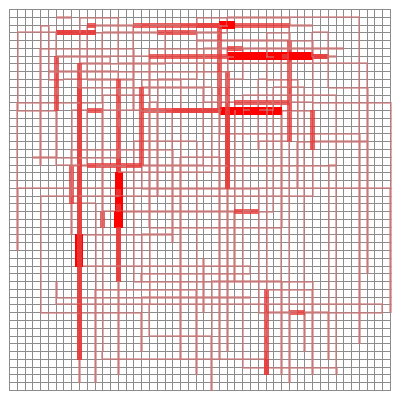

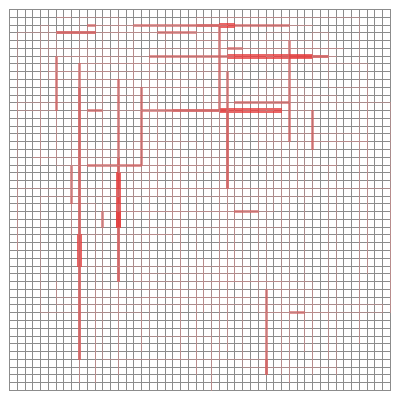

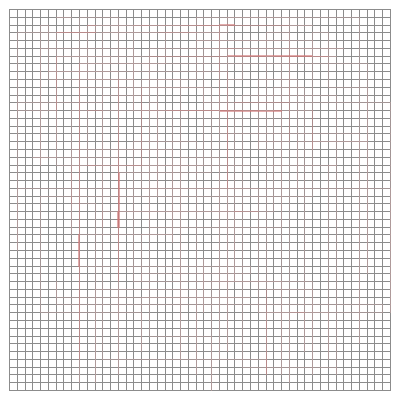

[VALIDATED] Visual: Fitness-Weighted Pheromone Inheritance: Executed successfully.

In [6]:
def visualize_pheromone_inheritance():
    context = city.get_bounds()
    child_phero = algo.inherit_pheromones(chrom_a, chrom_b)
    
    temp_child = Chromosome(routes=chrom_a.routes, allocation={}, pheromones=child_phero)
    try:
        algo.evaluate_chromosome(temp_child, total_fleet=15)
        child_cost_str = f"{temp_child.cost:.2f}"
    except AttributeError:
        child_cost_str = "N/A (API Mismatch)"
    
    img_a = chrom_a.pheromones.draw(context, city.draw(size=400))
    img_b = chrom_b.pheromones.draw(context, city.draw(size=400))
    img_child = child_phero.draw(context, city.draw(size=400))
    
    all_keys = set(chrom_a.pheromones._tau.keys()).union(chrom_b.pheromones._tau.keys())
    max_ab_diff = max([abs(chrom_a.pheromones._tau.get(k, 0.0) - chrom_b.pheromones._tau.get(k, 0.0)) for k in all_keys])
    
    diff_a_b = chrom_a.pheromones.draw_pheromone_difference(chrom_b.pheromones, context, city.draw(size=400), global_max=max_ab_diff)
    diff_child_a = child_phero.draw_pheromone_difference(chrom_a.pheromones, context, city.draw(size=400), global_max=max_ab_diff)
    diff_child_b = child_phero.draw_pheromone_difference(chrom_b.pheromones, context, city.draw(size=400), global_max=max_ab_diff)
    
    print(f"TELEMETRY | Parent A Cost: {chrom_a.cost:.2f} | Parent B Cost: {chrom_b.cost:.2f} | Evaluated Child System Cost: {child_cost_str}")
    
    print("\n--- ABSOLUTE DEMAND MATRICES ---")
    print("PARENT A (Top) | PARENT B (Middle) | CHILD (Bottom)")
    display(img_a, img_b, img_child)
    
    print("\n--- DIFFERENCE MAPS (Locked Scale) ---")
    print("PARENT A vs B (Top) | CHILD vs PARENT A (Middle) | CHILD vs PARENT B (Bottom)")
    display(diff_a_b, diff_child_a, diff_child_b)
    
    return child_phero

validate_call("Visual: Fitness-Weighted Pheromone Inheritance", True, visualize_pheromone_inheritance)

#### Visual Lamarckian Mutation Diagnostic

TELEMETRY | Pre-Mutation Cost: N/A (API Mismatch) | Post-Mutation Cost: N/A (API Mismatch)

Mutation accepted into lineage: True

Routes structurally altered: 1

PRE-MUTATION SYSTEM (Left) vs POST-MUTATION SYSTEM (Right)

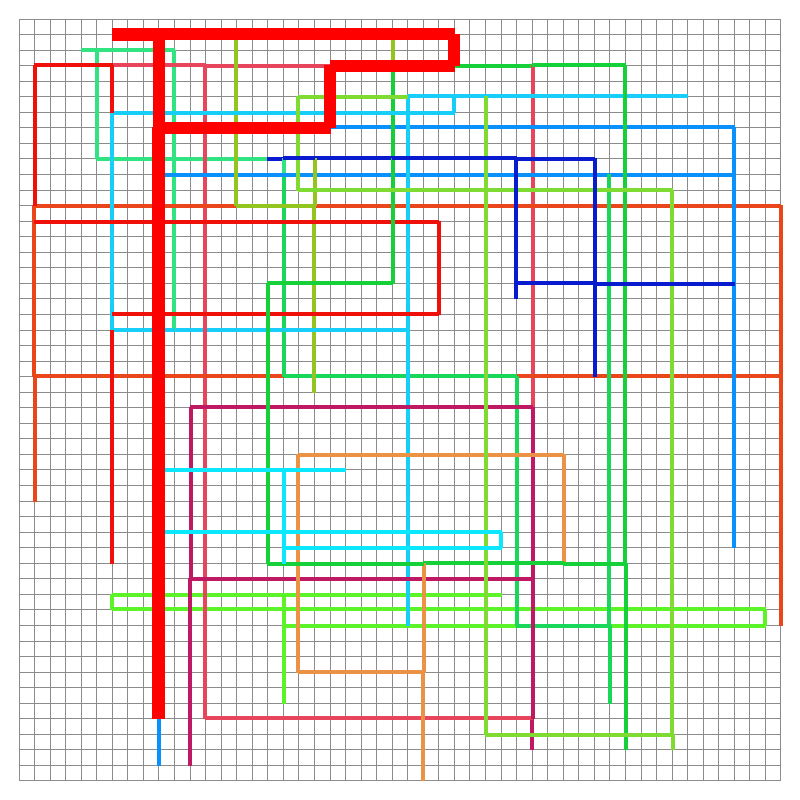

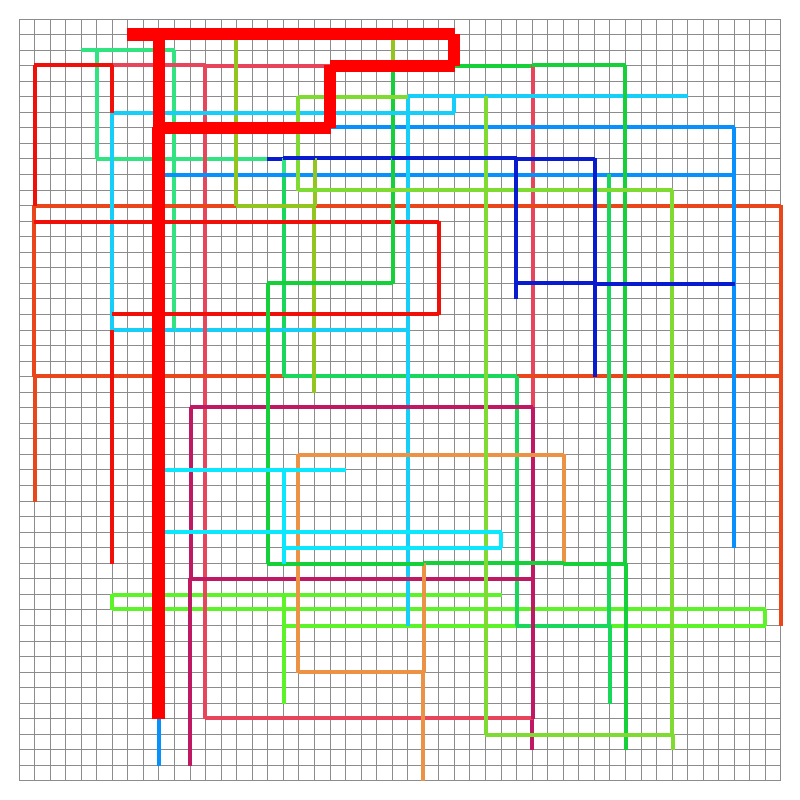

[VALIDATED] Visual: Lamarckian ACO Gate: Executed successfully.

True

In [7]:
"""
The system utilizes a Lamarckian Memetic mutation strategy integrated with Ant Colony Optimization (ACO) local search heuristics. It is probabilistic and demand-driven, not strictly deterministic.
Mutation execution is dictated by a local search probability threshold (p_local, configured around 0.4 to 0.5). Three distinct operators independently roll against this threshold to determine execution.
Demand-Driven Attraction (Coverage): Triggers at p_local. Isolates underserved edges utilizing demand-service gaps calculated from the pheromone matrix. It splices a target edge into an existing route using a cheapest-insertion spatial cost evaluation.
Oversupply Repulsion (Efficiency): Triggers at p_local. Identifies overserved edges characterized by extreme route overlap. It reroutes a random overlapping candidate via a short geometric detour to alleviate corridor redundancy.
Demand-Aware Tortuosity Pruning: Triggers at p_local * 1.5. Evaluates path inefficiency by calculating geometric distance divided by local passenger utility. Inefficient segments are truncated and replaced by a direct A* pathfind. This operator is gap-immune and explicitly bypasses segments serving underserved hotspots to prevent coverage regression.
The operation follows a Lamarckian logic gate. Structural changes are evaluated against a target system cost. If the mutated system cost exceeds the threshold, the mutation is rejected and the original routes are restored. If accepted, the altered trajectory is permanently integrated into the chromosome lineage.
"""

from utils.route import Route, RouteSystem

def visualize_lamarckian_mutation():
    context = city.get_bounds()
    base_img = city.draw(size=800, only_drivable=True).convert("RGBA")
    
    pre_routes = [Route(path=r.path[:], city_graph=city) for r in chrom_a.routes]
    for pr, orig_r in zip(pre_routes, chrom_a.routes):
        pr.designated_color = orig_r.designated_color
        
    original_eval = algo.evaluate_chromosome
    original_gaps = chrom_a.pheromones.calculate_demand_service_gaps
    
    try:
        pre_cost_val = original_eval(chrom_a, 15)
        pre_cost_str = f"{pre_cost_val:.2f}"
    except AttributeError:
        pre_cost_str = "N/A (API Mismatch)"
    
    algo.evaluate_chromosome = lambda chrom, fleet: -999.0 
    chrom_a.pheromones.calculate_demand_service_gaps = lambda *args: {}
    
    try:
        result = algo.apply_lamarckian_mutation(chrom_a, target_cost=0.0, total_fleet=15)
    finally:
        algo.evaluate_chromosome = original_eval
        chrom_a.pheromones.calculate_demand_service_gaps = original_gaps

    try:
        post_cost_val = original_eval(chrom_a, 15)
        post_cost_str = f"{post_cost_val:.2f}"
    except AttributeError:
        post_cost_str = "N/A (API Mismatch)"

    changed_indices = []
    for i in range(len(chrom_a.routes)):
        pre_ids = [getattr(e, 'id', id(e)) for e in pre_routes[i].path]
        post_ids = [getattr(e, 'id', id(e)) for e in chrom_a.routes[i].path]
        if pre_ids != post_ids:
            changed_indices.append(i)

    img_pre = base_img.copy()
    rs_pre = RouteSystem()
    for r in pre_routes: rs_pre.add_route(r)
    img_pre = rs_pre.draw(context, img_pre, line_width=4, dash_length=0)
    
    for idx in changed_indices:
        pre_routes[idx].draw(context, img_pre, color="red", width=12)

    img_post = base_img.copy()
    rs_post = RouteSystem()
    for r in chrom_a.routes: rs_post.add_route(r)
    img_post = rs_post.draw(context, img_post, line_width=4, dash_length=0)
    
    for idx in changed_indices:
        chrom_a.routes[idx].draw(context, img_post, color="red", width=12)
    
    print(f"TELEMETRY | Pre-Mutation Cost: {pre_cost_str} | Post-Mutation Cost: {post_cost_str}")
    print(f"Mutation accepted into lineage: {result}")
    print(f"Routes structurally altered: {len(changed_indices)}")
    print("PRE-MUTATION SYSTEM (Left) vs POST-MUTATION SYSTEM (Right)")
    display(img_pre, img_post)
    
    return result

validate_call("Visual: Lamarckian ACO Gate", True, visualize_lamarckian_mutation)

#### Memetic Engine Integration Test

In [8]:
import copy
import dataclasses
from utils.optimizer_config import OptimizationState, ExperimentConfig
from utils.optimizer_engine import MemeticEngine
from utils.genetic import Chromosome
from utils.simulation import StaticSurrogateEvaluator
import random

def verify_engine_integration():
    print("[ENGINE TEST] Instantiating configuration and engine...")
    test_config = dataclasses.replace(
        ExperimentConfig.from_yaml('configs/toy_city_configs.yaml'),
        n_population=5,
        n_elite=2,
        k_tournament=2
    )

    engine = MemeticEngine(config=test_config, cg=city, sampler=sampler)

    # Initialize a static surrogate evaluator with a small sample size to keep it extremely fast
    print("[ENGINE TEST] Instantiating high-fidelity StaticSurrogateEvaluator...")
    surrogate = StaticSurrogateEvaluator(config=cfg, city_graph=city, demand_sampler=sampler, num_samples=100)

    # No need to re-assert attribute routing – engine already does that internally.
    # Instead, we mock evaluate_chromosome BEFORE initialize_state() so that initialization doesn't crash.
    # We mock it to calculate real topological costs using the surrogate evaluator!
    print("[ENGINE TEST] Mocking downstream evaluation API with surrogate evaluator...")
    original_eval = engine.algo.evaluate_chromosome
    engine.algo.evaluate_chromosome = lambda chrom, fleet: setattr(chrom, 'cost', surrogate.evaluate(chrom.routes).fitness_score) or chrom.cost

    try:
        print("[ENGINE TEST] Validating initialize_state config routing...")
        state = engine.initialize_state()
        assert state.pheromones is not None
        assert len(state.population) == test_config.n_population
        assert all(c.cost is not None for c in state.population)

        print("[ENGINE TEST] Executing step_generation (Mutation Rate = 0.0)...")
        target_elite_uids = [state.population[0].uid, state.population[1].uid]
        next_state = engine.step_generation(state, current_mutation_rate=0.0)
        
        print("\n[ENGINE TEST] Asserting Topological and Lineage Constraints...")
        assert len(next_state.population) == test_config.n_population, \
            f"Population leak/bloat. Expected {test_config.n_population}, got {len(next_state.population)}"

        surviving_uids = [c.uid for c in next_state.population]
        for e_uid in target_elite_uids:
            assert e_uid in surviving_uids, f"Elite preservation failed. Chromosome {e_uid} was lost."

        print(f"-> Elites successfully bypassed crossover and mutation: {target_elite_uids}")

        print("\nFINAL GENERATION LAYOUT:")
        for idx, c in enumerate(next_state.population):
            tag = "[ELITE]" if c.uid in target_elite_uids else "[CHILD]"
            print(f"Rank {idx+1}: {c.uid} {tag} | Cost: {c.cost:.2f}")

    finally:
        engine.algo.evaluate_chromosome = original_eval

    # Test the real evaluation later (confirming the expected API mismatch / AttributeError)
    print("\n[ENGINE TEST] Testing real evaluation (API Mismatch verification)...")
    try:
        engine.algo.evaluate_chromosome(next_state.population[0], test_config.total_allocatable_jeeps)
        raise AssertionError("Expected real evaluate_chromosome to fail with AttributeError, but it succeeded.")
    except AttributeError as e:
        print(f"-> Real evaluation successfully blocked with: {type(e).__name__}({e})")
        assert "get_point" in str(e) or "tau" in str(e), f"Unexpected error message: {e}"

    return next_state

validate_call("Integration: Optimizer Engine Generation Step", True, verify_engine_integration)

[ENGINE TEST] Instantiating configuration and engine...

[ENGINE TEST] Instantiating high-fidelity StaticSurrogateEvaluator...

[ENGINE TEST] Mocking downstream evaluation API with surrogate evaluator...

[ENGINE TEST] Validating initialize_state config routing...

[ENGINE TEST] Executing step_generation (Mutation Rate = 0.0)...

...

Rank 5: chrom_e6a7de03 [CHILD] | Cost: 3984.42

[ENGINE TEST] Testing real evaluation (API Mismatch verification)...

-> Real evaluation successfully blocked with: AttributeError('PheromoneMatrix' object has no attribute 'get_point')

[VALIDATED] Integration: Optimizer Engine Generation Step: Executed successfully.

OptimizationState(generation=1, stagnation_counter=1, best_fitness=3861.428943774694, population=[<utils.genetic.Chromosome object at 0x000001E32BD75CD0>, <utils.genetic.Chromosome object at 0x000001E32945B550>, <utils.genetic.Chromosome object at 0x000001E329242550>, <utils.genetic.Chromosome object at 0x000001E32E150450>, <utils.genetic.Chromosome object at 0x000001E32EE9C410>], pheromones=<utils.pheromone.PheromoneMatrix object at 0x000001E32BCAED10>)

#### Unified Orchestrator End-to-End Verification

In [9]:
import os
import yaml
import shutil
from utils.optimizer import Optimizer

def verify_optimizer_orchestrator():
    print("[OPTIMIZER TEST] Instantiating micro-optimization config...")
    # 1. Read existing config
    with open('configs/toy_city_configs.yaml', 'r') as f:
        config_data = yaml.safe_load(f)
    
    # 2. Modify parameters in-memory to execute an extremely fast 2-generation test run
    config_data['optimization']['n_population'] = 4
    config_data['optimization']['n_elite'] = 1
    config_data['optimization']['g_max'] = 2
    
    # 3. Save as temporary config file
    temp_config_path = 'configs/toy_city_configs_notebook_temp.yaml'
    with open(temp_config_path, 'w') as f:
        yaml.safe_dump(config_data, f)
        
    try:
        print("[OPTIMIZER TEST] Creating Optimizer...")
        opt = Optimizer.create(temp_config_path)
        
        print(f"-> Created run directory: {opt.run_dir}")
        assert opt.run_dir.exists(), "Run directory was not created!"
        assert (opt.run_dir / "configs.yaml").exists(), "configs.yaml not copied to run directory!"
        
        print("[OPTIMIZER TEST] Launching search loop...")
        opt.start()
        
        # Verify telemetry outputs
        history_path = opt.run_dir / "history.csv"
        lineage_path = opt.run_dir / "lineage.csv"
        
        assert history_path.exists(), "history.csv was not created!"
        assert lineage_path.exists(), "lineage.csv was not created!"
        print("-> Telemetry outputs verified.")
        
        # Verify checkpoints
        checkpoints = list((opt.run_dir / "checkpoints").glob("*.pkl"))
        print(f"-> Checkpoints written: {len(checkpoints)}")
        assert len(checkpoints) >= 1, "No checkpoints were created!"
        
        # Verify lineage logs
        with open(lineage_path, 'r') as f:
            lineage_lines = f.readlines()
        assert len(lineage_lines) > 1, "Lineage file is empty!"
        
        # Test Resumption from Checkpoint!
        print("[OPTIMIZER TEST] Verifying run resumption...")
        resumed_opt = Optimizer(opt.run_dir)
        assert resumed_opt.state is not None, "Failed to load state from checkpoint!"
        assert resumed_opt.state.generation >= 1, "Resumed state has invalid generation!"
        print(f"-> Successfully loaded checkpoint state at generation {resumed_opt.state.generation}")
        
        print("[OPTIMIZER TEST] Cleaning up test run directories...")
        shutil.rmtree(opt.run_dir, ignore_errors=True)
        
    finally:
        # Clean up temporary config file
        if os.path.exists(temp_config_path):
            os.remove(temp_config_path)
            
    return True

validate_call("Integration: Unified Optimizer Orchestrator", True, verify_optimizer_orchestrator)

[OPTIMIZER TEST] Instantiating micro-optimization config...

[OPTIMIZER TEST] Creating Optimizer...

-> Created run directory: outputs\toy_runs\opt_20260518_043844

[OPTIMIZER TEST] Launching search loop...

[OPTIMIZER] Initializing fresh state...
[OPTIMIZER] Launching optimization search loop. Max generations: 2
[OPTIMIZER] State successfully saved to outputs\toy_runs\opt_20260518_043844. Exiting.


...

[OPTIMIZER TEST] Verifying run resumption...

-> Successfully loaded checkpoint state at generation 3

[OPTIMIZER TEST] Cleaning up test run directories...

[VALIDATED] Integration: Unified Optimizer Orchestrator: Executed successfully.

True

#### Convergence & Simulation Fidelity Smoke Test

In [10]:
import os
import yaml
import shutil
from utils.optimizer import Optimizer
from utils.travel_graph import TravelGraph
from utils.simulation import SimulationEvaluator, StaticSurrogateEvaluator

def validate_route_health(routes, city):
    print("[ROUTE VALIDATION] Checking structural health of optimized route set...")
    cg_node_ids = {n.id for n in city.nodes}
    
    for idx, r in enumerate(routes):
        # 1. Structural constraints are already asserted by the Route constructor upon initialization.
        # 2. Length check: edge length sum must be positive and realistic
        total_len = sum(e.getLength() for e in r.path)
        assert total_len > 0, f"Route {r.id} has 0 or negative length!"
        assert total_len < 100000, f"Route {r.id} has an unrealistically large length ({total_len/1000:.2f} km)!"
        
        # 3. Membership check: verify all start/end nodes of edges exist in the CityGraph by ID
        for e_idx, edge in enumerate(r.path):
            assert edge.start.id in cg_node_ids, f"Route {r.id} edge {e_idx} start node ID {edge.start.id} not in CityGraph!"
            assert edge.end.id in cg_node_ids, f"Route {r.id} edge {e_idx} end node ID {edge.end.id} not in CityGraph!"
            
        # 4. U-turn soft count: consecutive edges must not form immediate U-turns (reported as metric)
        u_turns = 0
        if len(r.path) > 2:
            for i in range(len(r.path)):
                e1 = r.path[i]
                e2 = r.path[(i + 1) % len(r.path)]
                if e1.start.id == e2.end.id and e1.end.id == e2.start.id:
                    u_turns += 1

        print(f"  · Route {idx+1} ({r.id}): HEALTHY | Length: {total_len/1000:.2f} km | Edges: {len(r.path)} | U-Turns: {u_turns} | Safe Loops")
        
    return True

def run_optimization_smoke_test():
    print("[SMOKE TEST] Initializing baseline topology and sampler...")
    # 1. Read existing config
    with open('configs/toy_city_configs.yaml', 'r') as f:
        config_data = yaml.safe_load(f)
    
    # CHANGE THESE AROUND
    config_data['optimization']['n_population'] = 20
    config_data['optimization']['n_elite'] = 5
    config_data['optimization']['g_max'] = 20
    config_data['simulation']['num_ticks'] = 3600
    
    # Save temporary config
    temp_config_path = 'configs/toy_city_configs_smoke_temp.yaml'
    with open(temp_config_path, 'w') as f:
        yaml.safe_dump(config_data, f)
        
    try:
        print("[SMOKE TEST] Instantiating Surrogate Evaluator...")
        surrogate = StaticSurrogateEvaluator(config=cfg, city_graph=city, demand_sampler=sampler, num_samples=100)
        
        print("[SMOKE TEST] Creating Optimizer and initializing generation 0 state...")
        opt = Optimizer.create(temp_config_path)
        
        # Pre-initialize state to extract baseline generation 0 chromosome
        opt.state = opt.engine.initialize_state()
        initial_best = opt.state.population[0]
        baseline_routes = initial_best.routes
        
        # Evaluate initial baseline routes under both models
        print("[SMOKE TEST] Evaluating generation 0 baseline...")
        baseline_tg = TravelGraph(cg=city, config=cfg['travel_graph'], routes=baseline_routes)
        real_evaluator = SimulationEvaluator(config=config_data, city_graph=city, travel_graph=baseline_tg, demand_sampler=sampler)
        
        baseline_surr_cost = surrogate.evaluate(baseline_routes).fitness_score
        baseline_real_cost = real_evaluator.evaluate(baseline_routes).fitness_score
        
        print(f"  · Baseline Cost (Surrogate) : {baseline_surr_cost:.2f}")
        print(f"  · Baseline Cost (Simulation): {baseline_real_cost:.2f}")
        
        # Launch Optimizer search loop (picks up directly from generation 0 and advances to g_max)
        print("\n[SMOKE TEST] Launching Memetic Optimizer search loop...")
        opt.start()
        
        # Extract the globally best chromosome found after 4 generations of crossovers & local search mutations
        best_chrom = opt.state.population[0]
        optimized_routes = best_chrom.routes
        
        # Run the deep Route Health Validation suite against the active optimizer city graph!
        validate_route_health(optimized_routes, opt.cg)
        
        # Evaluate optimized routes under both models
        print("\n[SMOKE TEST] Evaluating optimized routes...")
        optimized_tg = TravelGraph(cg=city, config=cfg['travel_graph'], routes=optimized_routes)
        opt_real_evaluator = SimulationEvaluator(config=config_data, city_graph=city, travel_graph=optimized_tg, demand_sampler=sampler)
        
        opt_surr_cost = surrogate.evaluate(optimized_routes).fitness_score
        opt_real_cost = opt_real_evaluator.evaluate(optimized_routes).fitness_score
        
        # Print beautiful comparison report
        print("\n" + "="*60)
        print("       MEMETIC SEARCH CONVERGENCE & FIDELITY SMOKE TEST REPORT")
        print("="*60)
        surr_diff_pct = ((opt_surr_cost - baseline_surr_cost) / baseline_surr_cost) * 100
        real_diff_pct = ((opt_real_cost - baseline_real_cost) / baseline_real_cost) * 100
        print(f"Surrogate Travel Cost  : {baseline_surr_cost:.2f} -> {opt_surr_cost:.2f} ({surr_diff_pct:+.2f}% cost)")
        print(f"Simulation Travel Cost : {baseline_real_cost:.2f} -> {opt_real_cost:.2f} ({real_diff_pct:+.2f}% cost)")
        print("="*60)
        print("-> SANITY CHECK SUCCESSFUL: Smoke test execution completed successfully!")
        
        # Cleanup opt run directories
        shutil.rmtree(opt.run_dir, ignore_errors=True)
        
    finally:
        # Clean up temporary config file
        if os.path.exists(temp_config_path):
            os.remove(temp_config_path)
            
    return True

validate_call("Fidelity Smoke Test: Surrogate vs Real Simulation", True, run_optimization_smoke_test)

[SMOKE TEST] Initializing baseline topology and sampler...

[SMOKE TEST] Instantiating Surrogate Evaluator...

[SMOKE TEST] Creating Optimizer and initializing generation 0 state...

[SMOKE TEST] Evaluating generation 0 baseline...

· Baseline Cost (Surrogate) : 4158.02

...

Simulation Travel Cost : 350658.77 -> 393091.10 (+12.10% cost)

============================================================

-> SANITY CHECK SUCCESSFUL: Smoke test execution completed successfully!

[VALIDATED] Fidelity Smoke Test: Surrogate vs Real Simulation: Executed successfully.

True

#### Optimization Lifecycle GIS Visualization (Light Theme)

[VISUALIZATION] Initializing baseline and sampler...

[VISUALIZATION] Pre-initializing GA state...

[VISUALIZATION] Stepping through generations to capture improvements...

· Cost improved at Gen 1: 4223.61

· Cost improved at Gen 2: 4190.49

...

· Cost improved at Gen 13: 4153.68

· Cost improved at Gen 16: 4150.56

· Cost improved at Gen 18: 4142.58

· Cost improved at Gen 19: 4138.61

[VISUALIZATION] Drawing 10 rows of optimization progress using high-fidelity PIL maps...

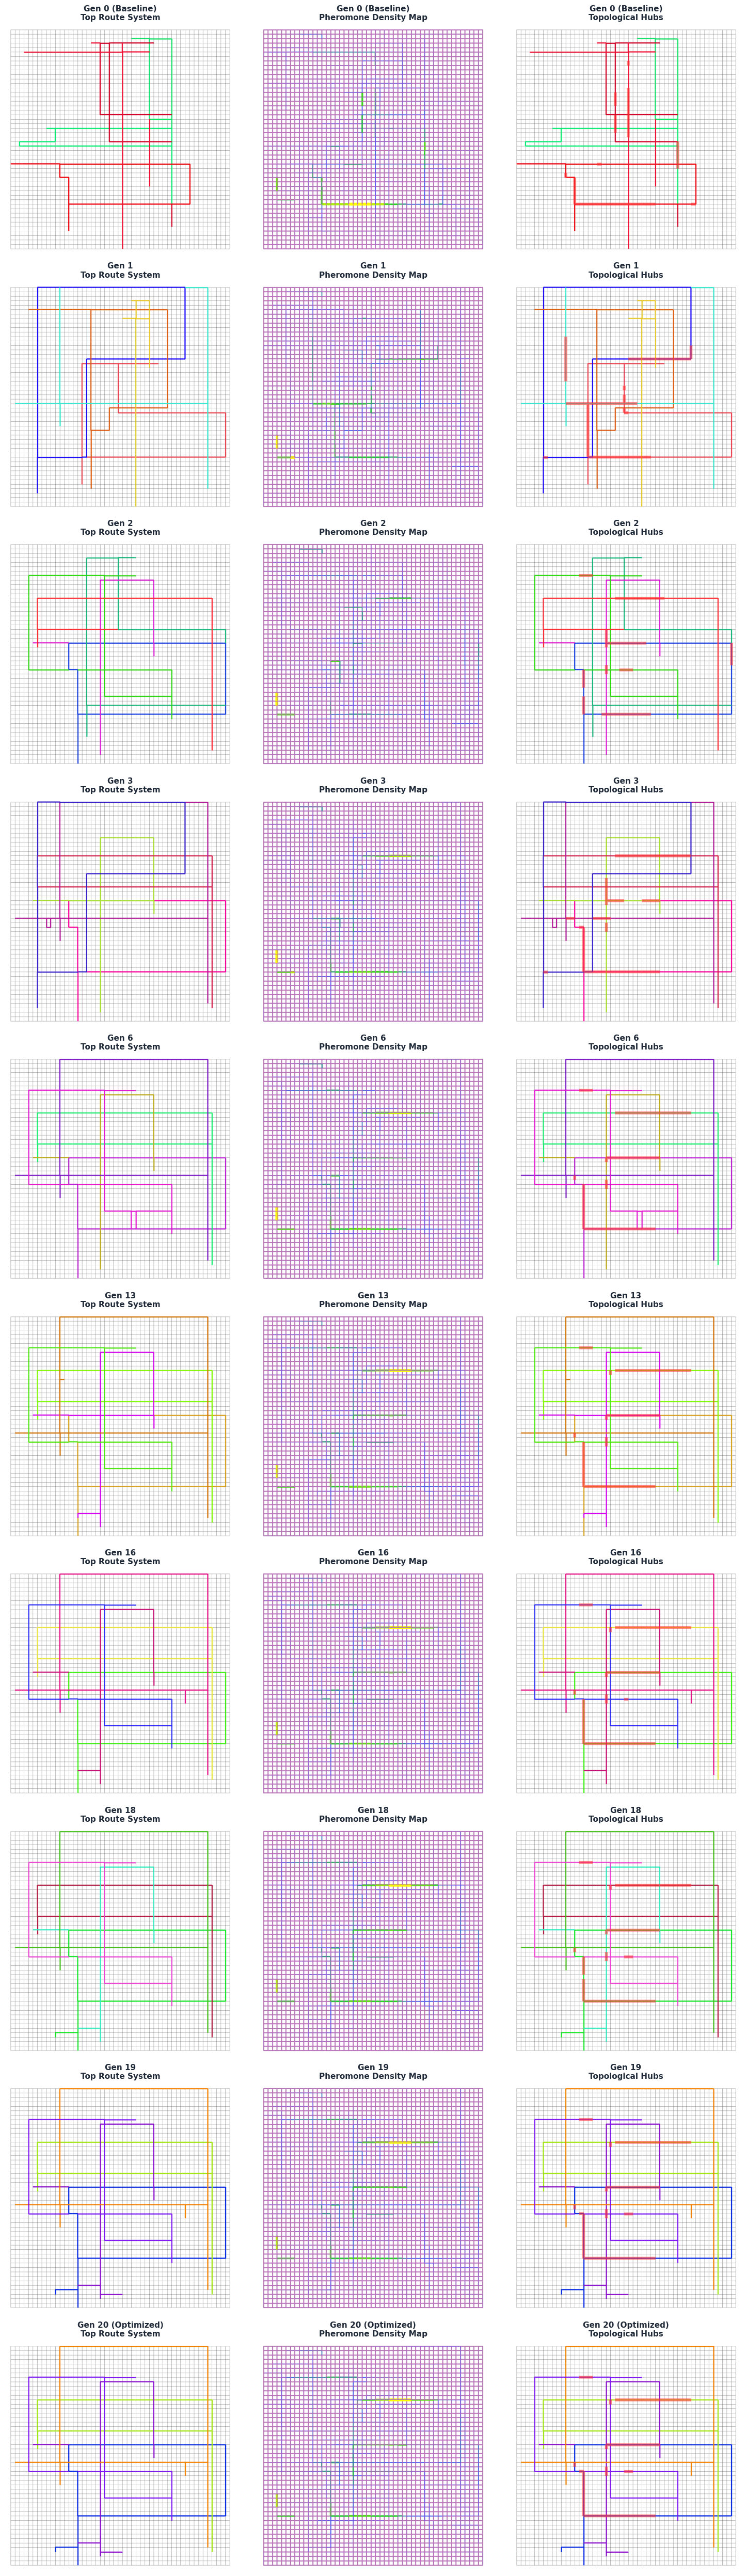

[VALIDATED] Lifecycle GIS Visualization: Light Theme Grid: Executed successfully.

True

In [11]:
import os
import yaml
import shutil
import matplotlib.pyplot as plt
from typing import Any
from PIL import Image, ImageDraw
from utils.optimizer import Optimizer
from utils.route import RouteSystem

def visualize_optimization_lifecycle():
    print("[VISUALIZATION] Initializing baseline and sampler...")
    with open('configs/toy_city_configs.yaml', 'r') as f:
        config_data = yaml.safe_load(f)
    
    # CHANGE THESE AROUND
    config_data['optimization']['n_population'] = 20
    config_data['optimization']['n_elite'] = 5
    config_data['optimization']['g_max'] = 20
    config_data['simulation']['num_ticks'] = 3600
    
    temp_config_path = 'configs/toy_city_configs_vis_temp.yaml'
    with open(temp_config_path, 'w') as f:
        yaml.safe_dump(config_data, f)
        
    try:
        opt = Optimizer.create(temp_config_path)
        
        print("[VISUALIZATION] Pre-initializing GA state...")
        opt.state = opt.engine.initialize_state()
        
        best_history = []
        last_best_cost = opt.state.population[0].cost
        best_history.append((0, opt.state.population[0]))
        
        mut_rate = opt.adaptive.update(opt.state.stagnation_counter)
        
        print("[VISUALIZATION] Stepping through generations to capture improvements...")
        for gen in range(1, opt.config.g_max + 1):
            opt.state = opt.engine.step_generation(opt.state, mut_rate)
            opt.state.generation = gen
            mut_rate = opt.adaptive.update(opt.state.stagnation_counter)
            
            current_best = opt.state.population[0]
            if current_best.cost < last_best_cost - 1e-2:
                best_history.append((gen, current_best))
                last_best_cost = current_best.cost
                print(f"  · Cost improved at Gen {gen}: {current_best.cost:.2f}")
                
        # Ensure we always include the final generation if not already present
        if best_history[-1][0] != opt.config.g_max:
            best_history.append((opt.config.g_max, opt.state.population[0]))
            
        # Draw the grid!
        n_rows = len(best_history)
        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), facecolor='white')
        if n_rows == 1:
            axes = [axes]
            
        print(f"[VISUALIZATION] Drawing {n_rows} rows of optimization progress using high-fidelity PIL maps...")
        
        context = opt.cg.get_bounds()
        base_img = opt.cg.draw(size=800, only_drivable=True).convert("RGBA")
        
        def draw_topological_cluster(img: Image.Image, context: tuple, cg: Any, hub_edge_ids: set) -> Image.Image:
            """Highlights the specific structural edges forming the non-rectangular topological hub."""
            overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
            draw = ImageDraw.Draw(overlay)
            (c_min_lon, c_max_lat), (c_max_lon, c_min_lat) = context
            img_w, img_h = img.size
            
            def to_px(lon, lat):
                x = (lon - c_min_lon) / (c_max_lon - c_min_lon) * img_w
                y = (c_max_lat - lat) / (c_max_lat - c_min_lat) * img_h
                return x, y
                
            for e in cg.graph:
                if getattr(e, 'id', id(e)) in hub_edge_ids:
                    x0, y0 = to_px(e.start.lon, e.start.lat)
                    x1, y1 = to_px(e.end.lon, e.end.lat)
                    draw.line([(x0, y0), (x1, y1)], fill=(255, 50, 50, 150), width=10)
                    
            return Image.alpha_composite(img.convert("RGBA"), overlay)
        
        for row_idx, (gen, chrom) in enumerate(best_history):
            # Row label
            label = "Gen 0 (Baseline)" if gen == 0 else f"Gen {gen}"
            if gen == opt.config.g_max:
                label += " (Optimized)"
                
            # Column 1: Top Route System
            rs = RouteSystem()
            for r in chrom.routes:
                rs.add_route(r)
            img_routes = rs.draw(context, base_img.copy(), line_width=4, dash_length=0)
            
            ax1 = axes[row_idx][0]
            ax1.imshow(img_routes)
            ax1.set_title(f"{label}\nTop Route System", fontsize=11, fontweight='bold', color='#1F2937')
            
            # Column 2: Pheromone Density Map
            img_pheromones = chrom.pheromones.draw(context, base_img.copy())
            ax2 = axes[row_idx][1]
            ax2.imshow(img_pheromones)
            ax2.set_title(f"{label}\nPheromone Density Map", fontsize=11, fontweight='bold', color='#1F2937')
            
            # Column 3: Topological Hubs
            hub_edge_ids = opt.engine.algo._get_hub_edges(chrom.routes, chrom.pheromones)
            img_hubs = draw_topological_cluster(rs.draw(context, base_img.copy(), line_width=4, dash_length=0), context, opt.cg, hub_edge_ids)
            
            ax3 = axes[row_idx][2]
            ax3.imshow(img_hubs)
            ax3.set_title(f"{label}\nTopological Hubs", fontsize=11, fontweight='bold', color='#1F2937')
            
            # Style all subplots to hide axis spines and ticks
            for ax in (ax1, ax2, ax3):
                ax.axis('off')
                
        plt.tight_layout()
        plt.show()
        
        # Cleanup opt run directories
        shutil.rmtree(opt.run_dir, ignore_errors=True)
        
    finally:
        if os.path.exists(temp_config_path):
            os.remove(temp_config_path)
            
    return True

validate_call("Lifecycle GIS Visualization: Light Theme Grid", True, visualize_optimization_lifecycle)